In [33]:
import torch
import json
import numpy as np
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import os
import sys
from pathlib import Path

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from dataset import TextPaletteDataset
from models.model import PaletteModel
from utils.color_utils import normalized_lab_to_rgb
from utils.checkpoint_utils import load_model_for_inference

In [ ]:
model_path = (
    "model.safetensors"  # Path to inference model weights (.safetensors / .pth / .pt)
)
config_path = Path.cwd().parent / "configs/config.yaml"

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_model_for_inference(config_path, model_path)
model.to(device)
model.eval()

PaletteModel(
  (clip_text): CLIPTextModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=

In [36]:
@torch.no_grad()
def embed_palette(model, palette, palette_mask):
    """
    palette: [S, 3]
    palette_mask: [S] True = valid
    """
    colors = palette[palette_mask]
    emb = model.color_embed(colors)  # [N, D]
    return emb.mean(dim=0)  # [D]


@torch.no_grad()
def embed_text(model, text):
    tokens = model.tokenizer(
        text,
        max_length=model.tokenizer_input_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(device)

    text_feats = model.clip_text(**tokens).last_hidden_state
    text_feats = model.text_proj(text_feats)

    return text_feats.mean(dim=1).squeeze(0)  # [D]

In [37]:
from inference.test_prompts import test_prompts

prompts = test_prompts

text_embs = []
palette_embs = []
avg_colors = []

for p in prompts:
    t = embed_text(model, p)
    text_embs.append(t.cpu().numpy())

    palette = model.generate(p, palette_size=5, deterministic=True)  # [1,S,3]
    palette = palette.squeeze(0)
    rgb = normalized_lab_to_rgb(palette.cpu()) / 255
    avg = rgb.mean(axis=0)  # [3]
    avg_colors.append(avg)
    mask = torch.ones(palette.shape[0], dtype=torch.bool, device=palette.device)

    pe = embed_palette(model, palette, mask)
    palette_embs.append(pe.cpu().numpy())

text_embs = np.stack(text_embs)
palette_embs = np.stack(palette_embs)
avg_colors = np.stack(avg_colors)

In [38]:
tsne_text = TSNE(n_components=2, random_state=42)
tsne_palette = TSNE(n_components=2, random_state=42)

text_2d = tsne_text.fit_transform(text_embs)
palette_2d = tsne_palette.fit_transform(palette_embs)

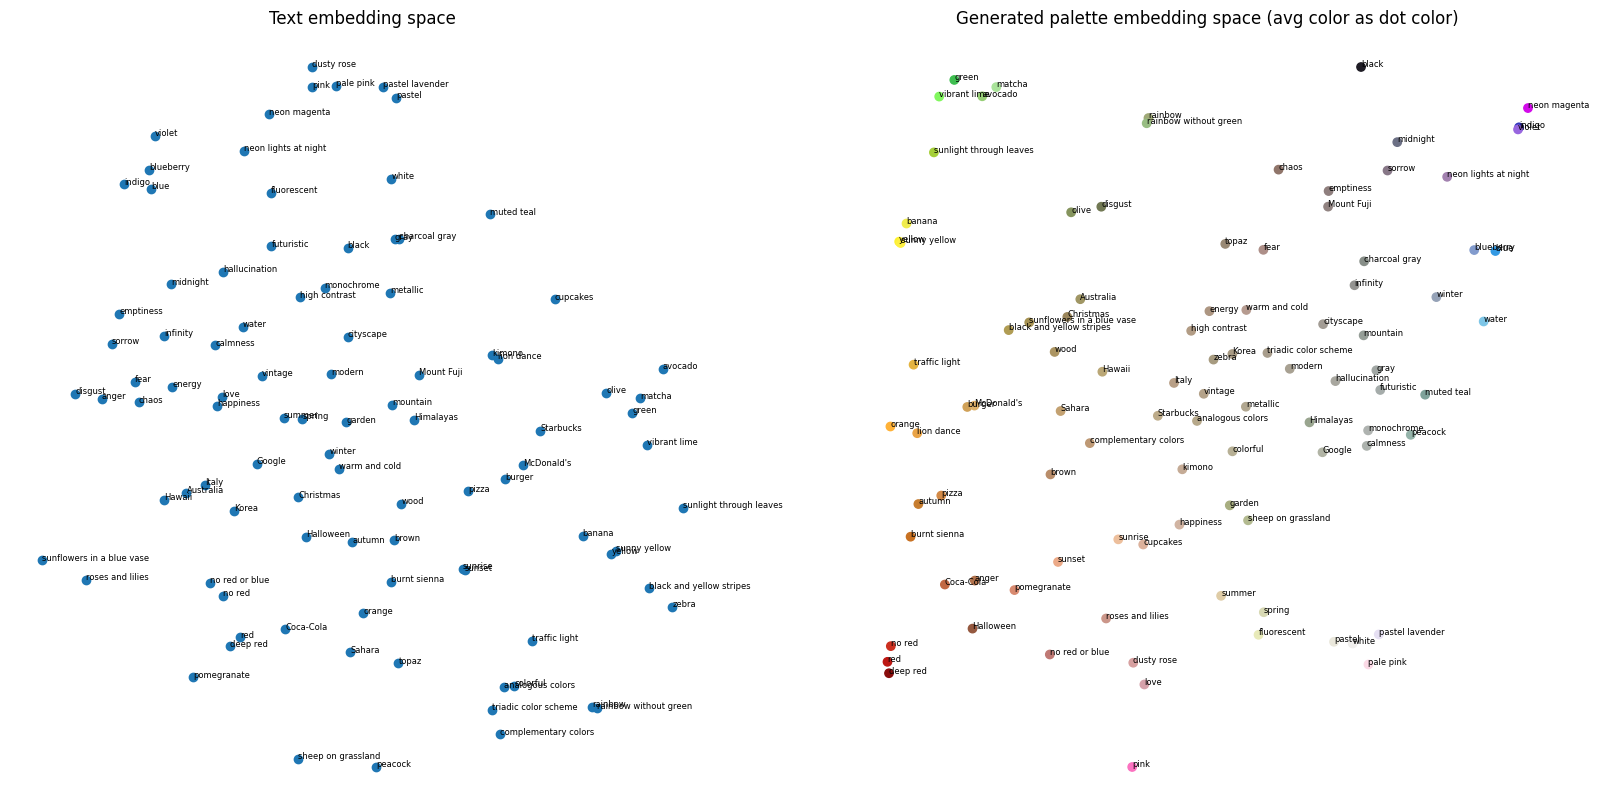

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Text space
axes[0].scatter(text_2d[:, 0], text_2d[:, 1])
for i, p in enumerate(prompts):
    axes[0].text(text_2d[i, 0], text_2d[i, 1], p, fontsize=6)
axes[0].set_title("Text embedding space")
axes[0].axis("off")

# Palette space
axes[1].scatter(palette_2d[:, 0], palette_2d[:, 1], c=avg_colors)
for i, p in enumerate(prompts):
    axes[1].text(palette_2d[i, 0], palette_2d[i, 1], p, fontsize=6)
axes[1].set_title("Generated palette embedding space (avg color as dot color)")
axes[1].axis("off")

plt.show()